In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
import os

seed = 0 # Setting seed for consistent results
np.random.seed(seed)
tf.random.set_seed(seed)

In [2]:
import pandas_datareader.data as web

In [3]:
import os
import datetime
import pandas_datareader.data as web

# Option 1: Pass key directly
f = web.DataReader("NVDA", "av-daily",
                   start=datetime.datetime(2000, 1, 1),
                   end=datetime.datetime(2025, 5, 20),
                   api_key='I2N82Z5V5S53BZ95')
f.to_csv('NVDA.csv')

In [4]:
companies = ['AMZN.csv', 'AAPL.csv', 'GOOG.csv', 'META.csv', 'MSFT.csv', 'NVDA.csv', 'TSLA.csv']

In [5]:
import pandas as pd
import os

def preprocess_high_column(folder='stock_data', file_list=None):
    """
    Preprocesses the 'High' column in each CSV file.
    Uses 'Unnamed: 0' as the date column.
    Returns: List of DataFrames as df_0, df_1, ...
    """
    if file_list is None:
        file_list = ['AMZN.csv', 'AAPL.csv', 'GOOG.csv', 'META.csv', 'MSFT.csv', 'NVDA.csv', 'TSLA.csv']
    
    dfs = []

    for file in file_list:
        path = os.path.join(folder, file)
        df = pd.read_csv(path)
        df = df.rename(columns={'Unnamed: 0': 'Date'})  # Rename index column to 'Date'
        df = df[['Date', 'high']].dropna()
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
        dfs.append(df)
    
    # Assign df_0, df_1, ... to global namespace
    for i, d in enumerate(dfs):
        globals()[f'df_{i}'] = d
    
    return dfs


In [6]:
'''
df_1->i values

Amazon = 0
Apple = 1
Google 2
Meta = 3
Microsoft = 4
Nvidia = 5
Tesla = 6
'''

'\ndf_1->i values\n\nAmazon = 0\nApple = 1\nGoogle 2\nMeta = 3\nMicrosoft = 4\nNvidia = 5\nTesla = 6\n'

In [7]:
preprocess_high_column(folder='stock_data', file_list=None)

[           Date      high
 0    2000-01-03   89.5600
 1    2000-01-04   91.5000
 2    2000-01-05   75.1300
 3    2000-01-06   72.6900
 4    2000-01-07   70.5000
 ...         ...       ...
 6379 2025-05-14  211.9300
 6380 2025-05-15  206.8800
 6381 2025-05-16  206.8500
 6382 2025-05-19  206.6200
 6383 2025-05-20  205.5899
 
 [6384 rows x 2 columns],
            Date    high
 0    2000-01-03  112.50
 1    2000-01-04  110.62
 2    2000-01-05  110.56
 3    2000-01-06  107.00
 4    2000-01-07  101.00
 ...         ...     ...
 6379 2025-05-14  213.94
 6380 2025-05-15  212.96
 6381 2025-05-16  212.57
 6382 2025-05-19  209.48
 6383 2025-05-20  208.47
 
 [6384 rows x 2 columns],
            Date    high
 0    2014-03-27  568.00
 1    2014-03-28  566.43
 2    2014-03-31  567.00
 3    2014-04-01  568.45
 4    2014-04-02  604.83
 ...         ...     ...
 2800 2025-05-14  168.34
 2801 2025-05-15  167.51
 2802 2025-05-16  170.65
 2803 2025-05-19  167.95
 2804 2025-05-20  169.68
 
 [2805 rows x 2 co

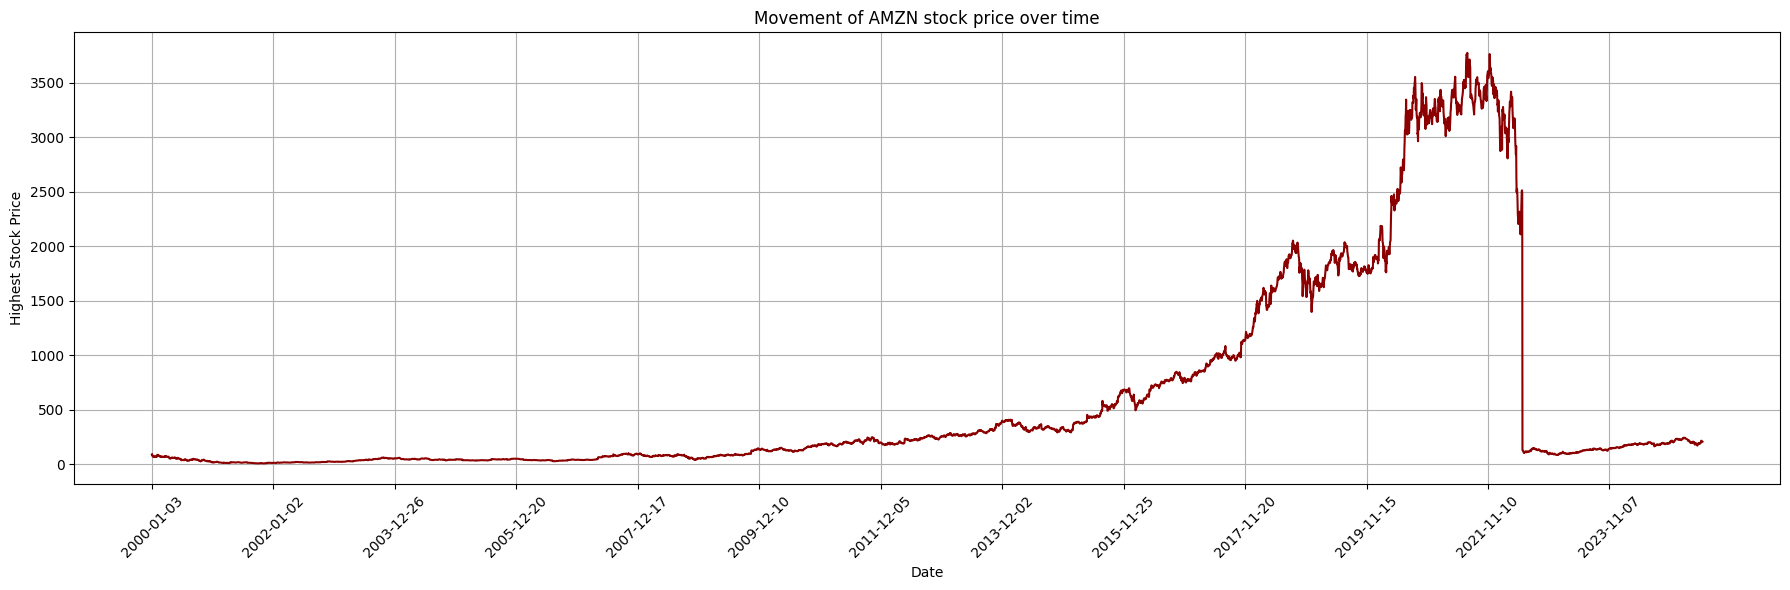

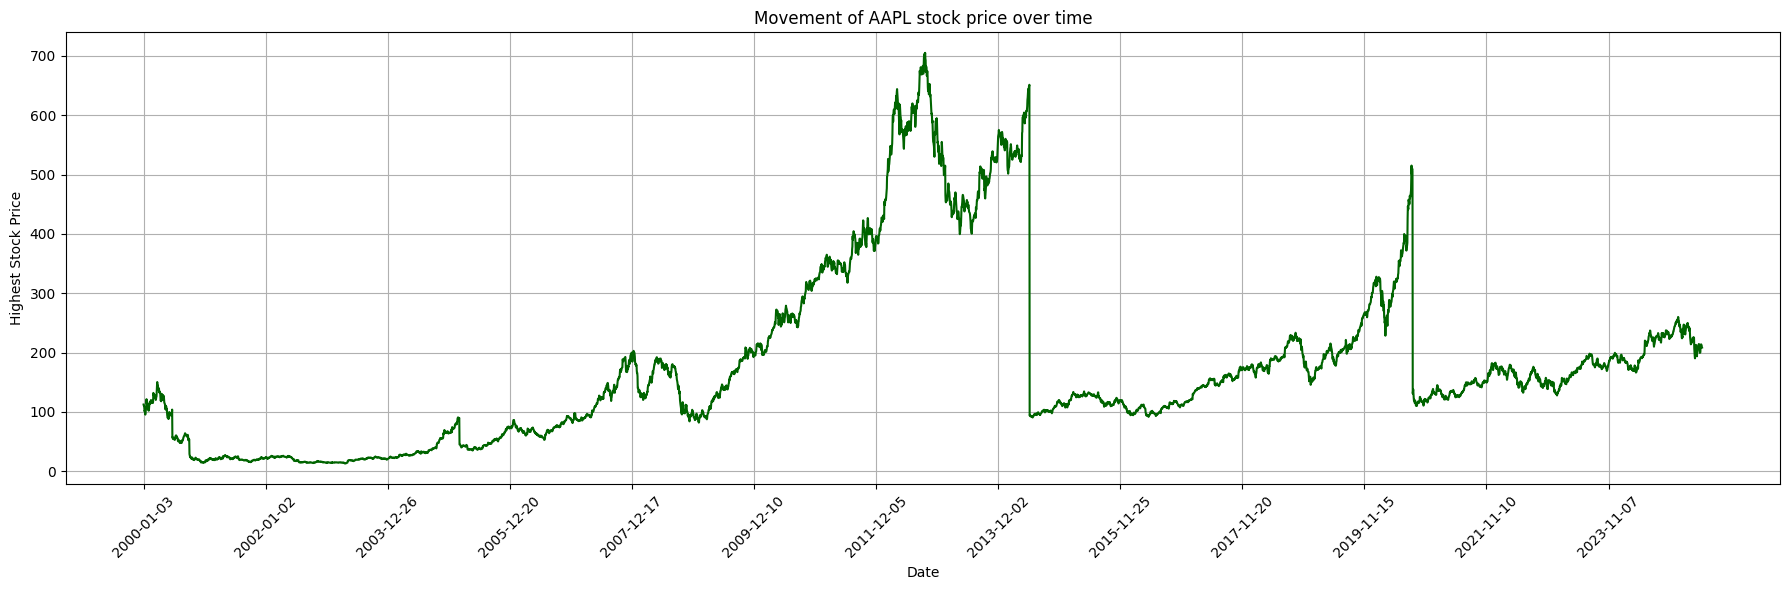

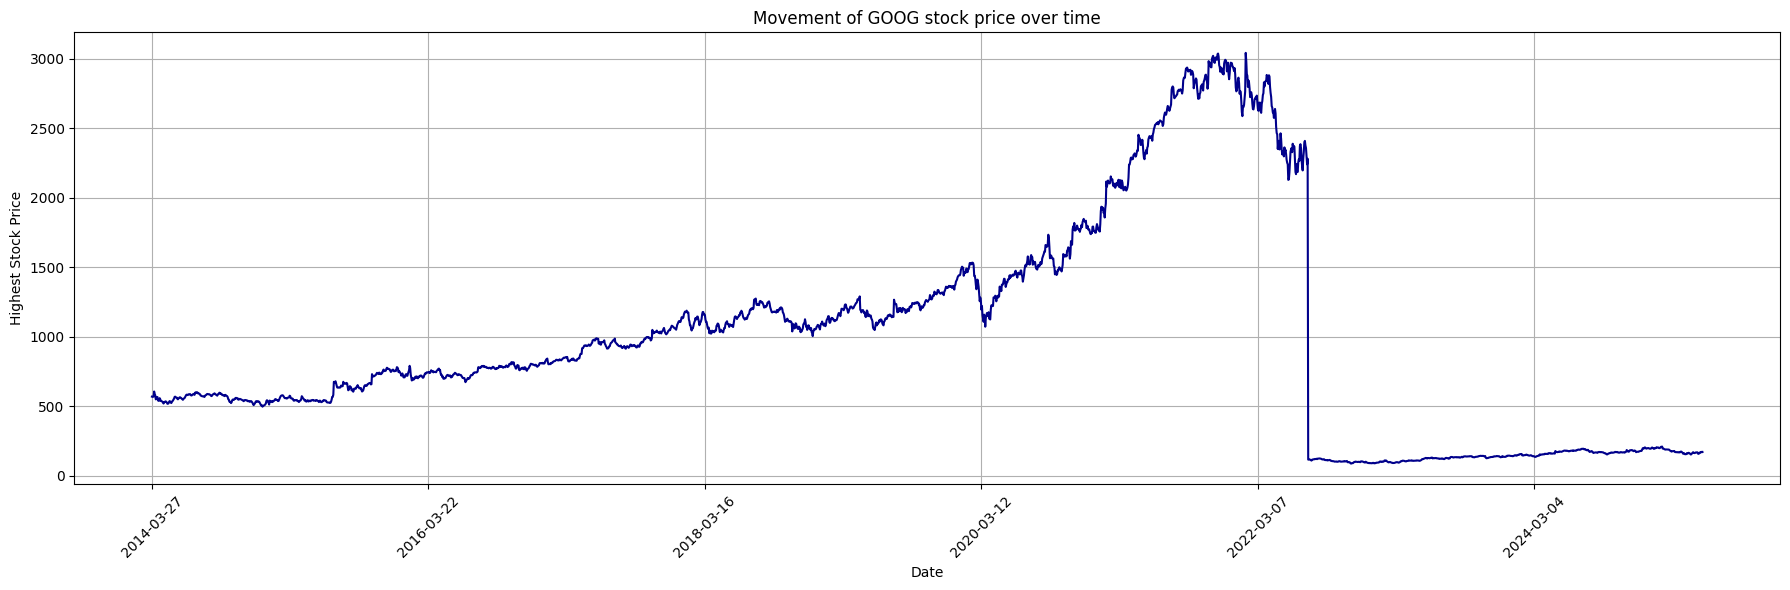

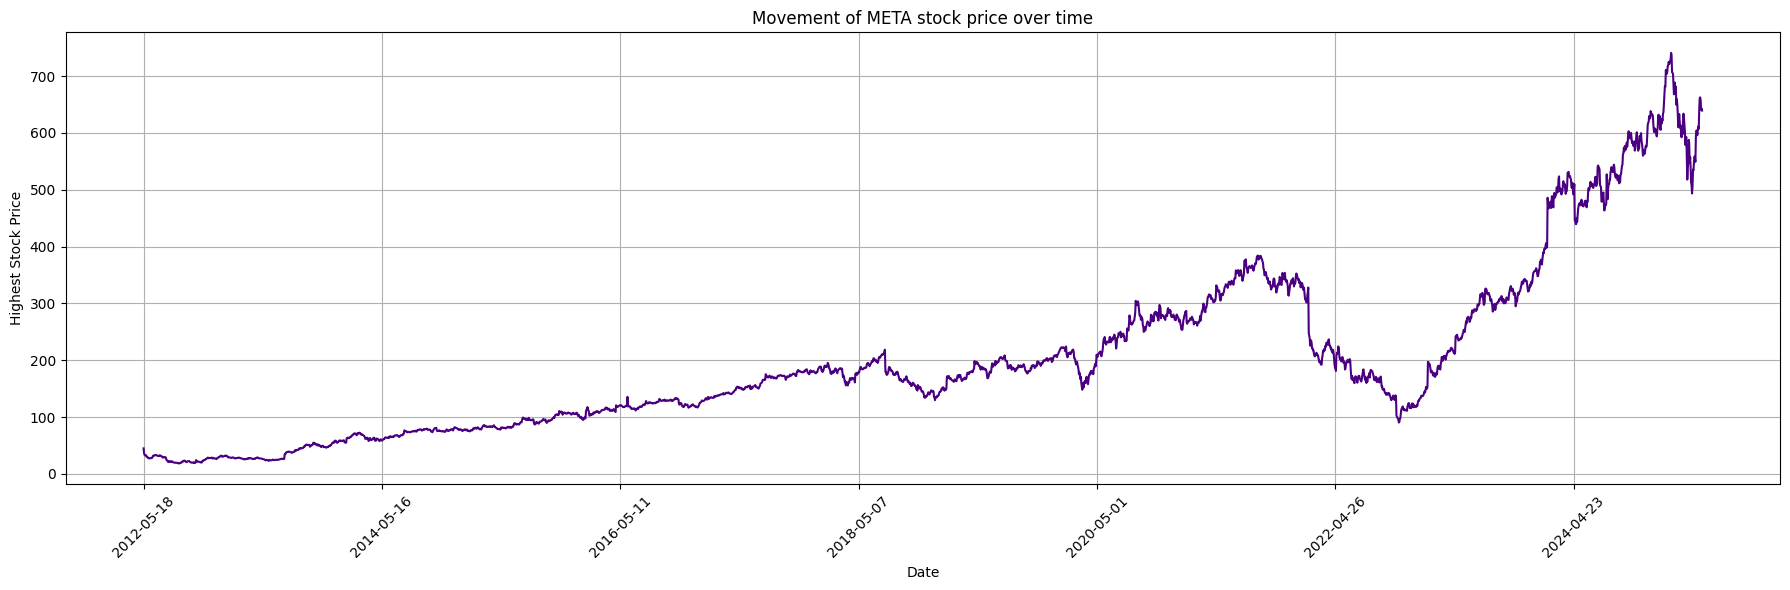

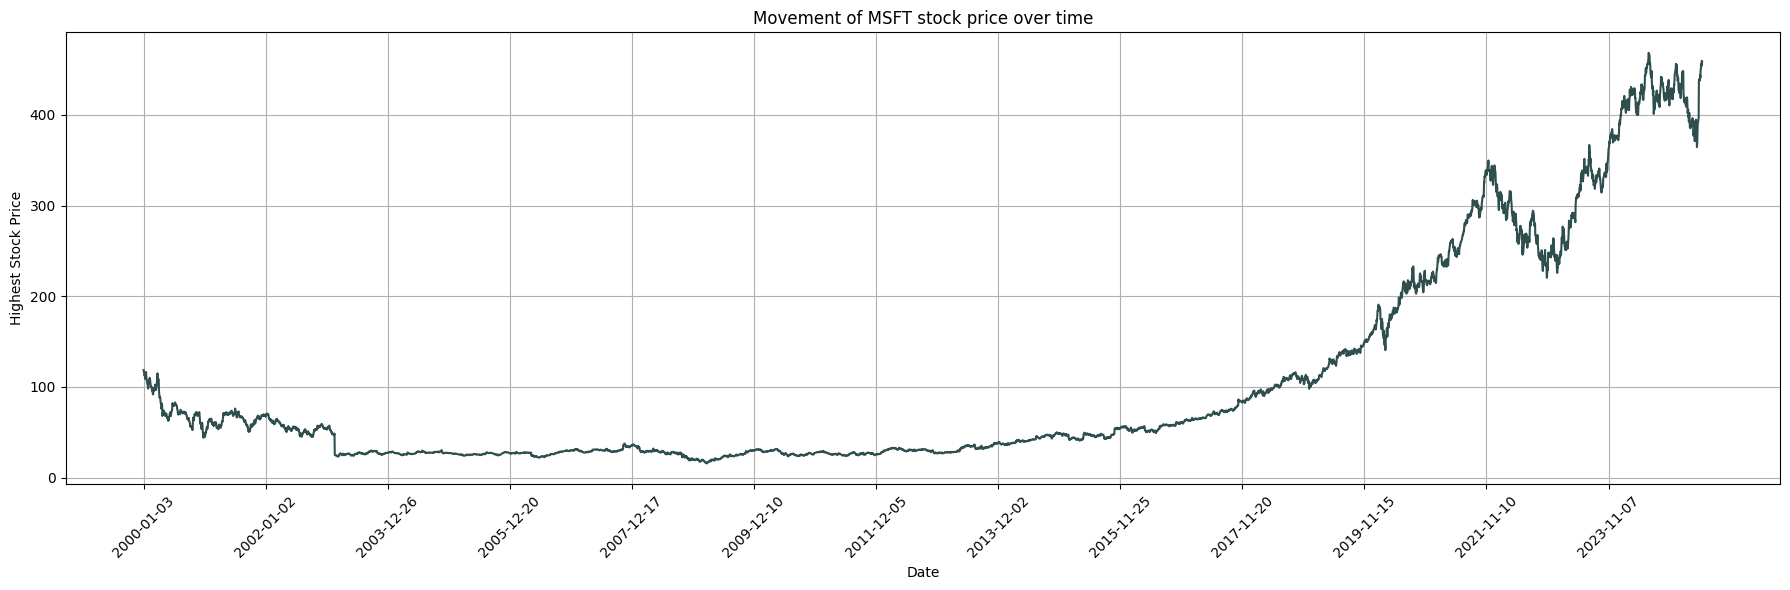

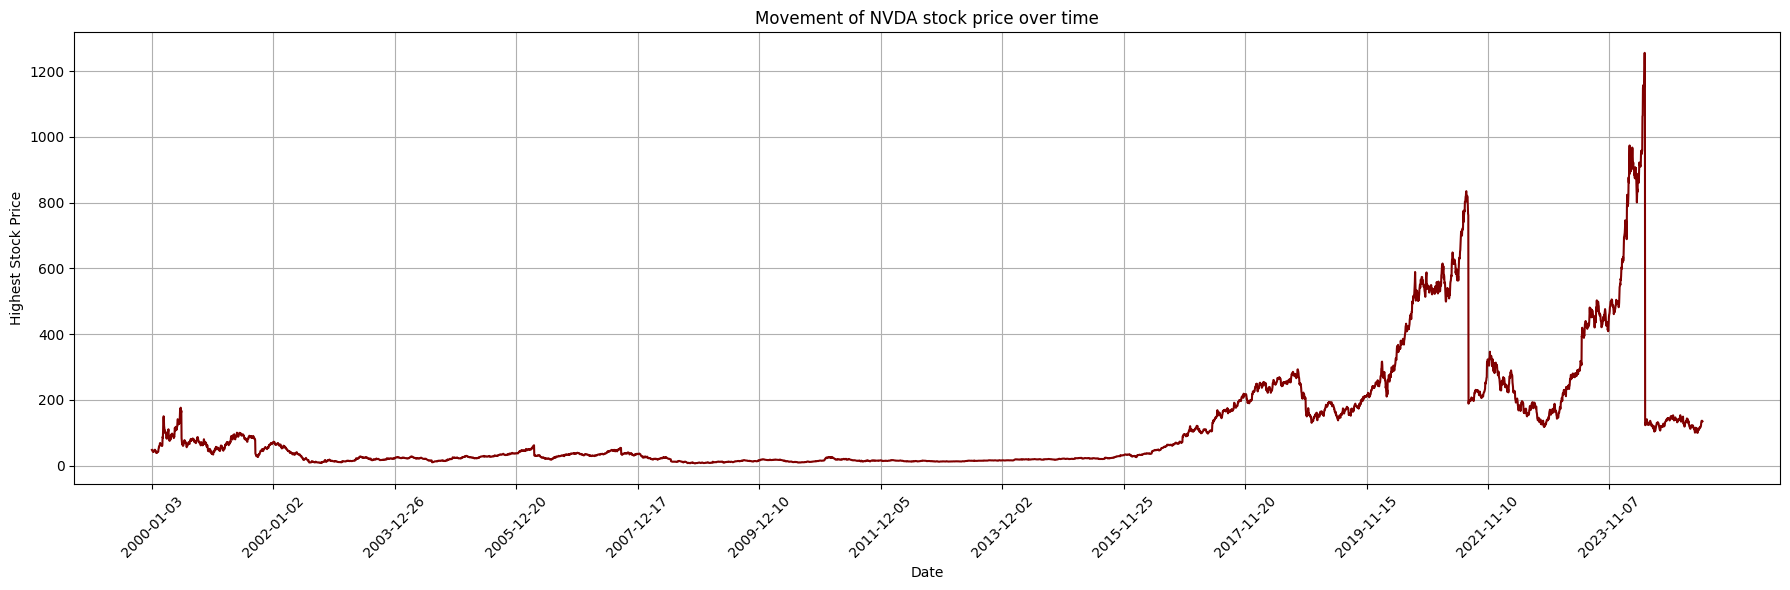

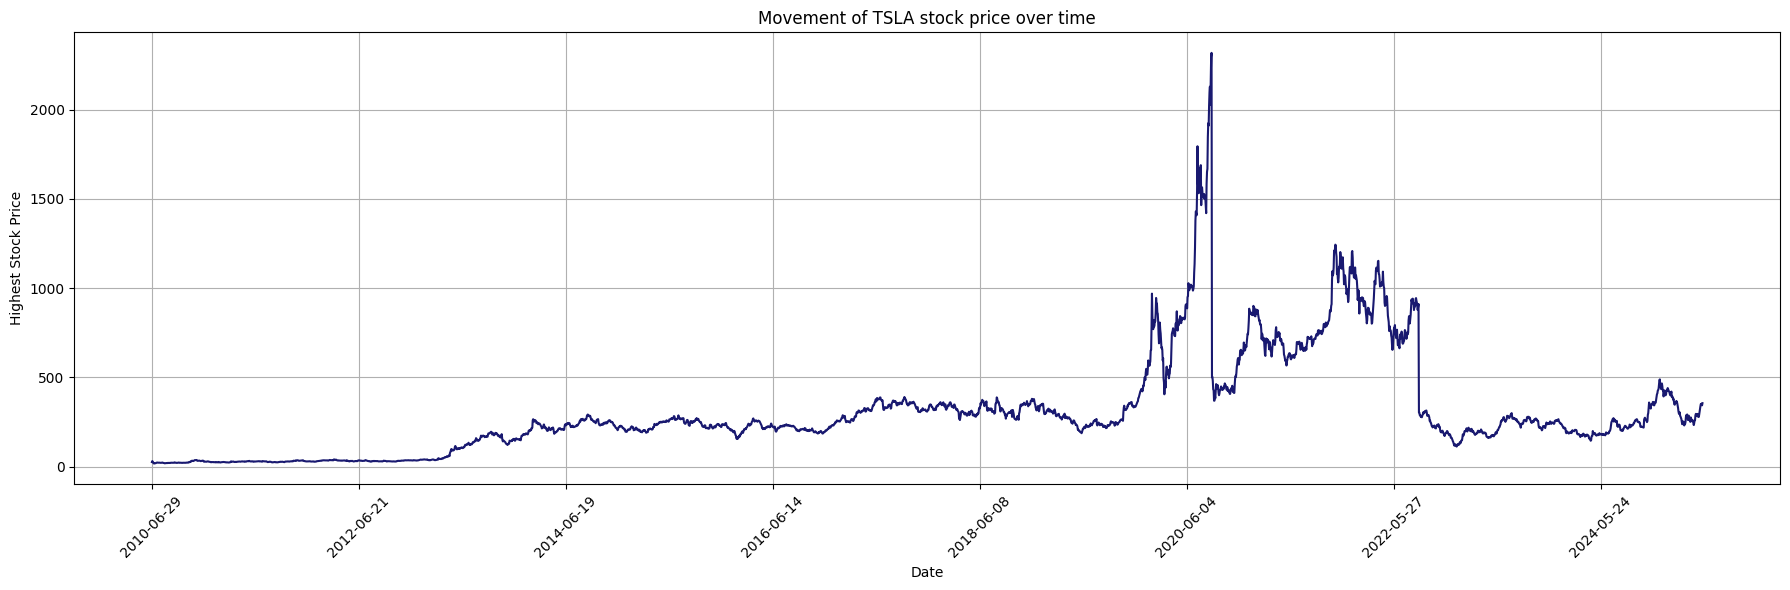

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os

folder = 'stock_data'
output_folder = 'stock_plots'  # folder to save plots
os.makedirs(output_folder, exist_ok=True)

companies = ['AMZN', 'AAPL', 'GOOG', 'META', 'MSFT', 'NVDA', 'TSLA']

# Dark color palette
company_colors = {
    'AMZN': '#8B0000',   # Dark Red
    'AAPL': '#006400',   # Dark Green
    'GOOG': '#00008B',   # Dark Blue
    'META': '#4B0082',   # Indigo
    'MSFT': '#2F4F4F',   # Dark Slate Gray
    'NVDA': '#800000',   # Maroon
    'TSLA': '#191970'    # Midnight Blue
}

for company in companies:
    file_path = os.path.join(folder, f"{company}.csv")
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Unnamed: 0'])
    df = df.sort_values('Date')
    
    high_prices = df['high'].reset_index(drop=True)
    color = company_colors.get(company, '#000000')  # fallback color

    plt.figure(figsize=(18,6))
    plt.plot(high_prices, color=color)
    plt.xticks(range(0, len(df), 500), df['Date'].dt.strftime('%Y-%m-%d').iloc[::500], rotation=45)
    plt.xlabel('Date')
    plt.ylabel('Highest Stock Price')
    plt.title(f'Movement of {company} stock price over time')
    plt.grid(True)
    plt.tight_layout()
    
    # Save plot
    save_path = os.path.join(output_folder, f"{company}_high_price.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def generate_moving_averages_csv(companies, folder='stock_data', save_fig=False):
    moving_average_periods = [10, 20, 50]
    output_folder = os.path.join(folder, "with_MA")
    os.makedirs(output_folder, exist_ok=True)

    for company in companies:
        file_path = os.path.join(folder, f"{company}.csv")
        df = pd.read_csv(file_path)
        df['Date'] = pd.to_datetime(df['Unnamed: 0'])
        df = df.sort_values('Date')
        
        for ma in moving_average_periods:
            df[f'high MA {ma}'] = df['high'].rolling(ma).mean()

        save_path = os.path.join(output_folder, f"{company}_with_MA.csv")
        df.to_csv(save_path, index=False)
        print(f"Saved {company} dataset with MAs at: {save_path}")
        
        plot_moving_averages_csv(df, company, save_fig, output_folder)

def plot_moving_averages_csv(df, company, save_fig, output_folder):
    plt.figure(figsize=(14,6))
    df[['high MA 10', 'high MA 20', 'high MA 50']].plot(ax=plt.gca(), linewidth = 0.5)

    idx = range(0, len(df), 250)
    xlabels = df['Date'].dt.strftime('%Y-%m-%d').iloc[idx]

    plt.xticks(idx, xlabels, rotation=40, fontsize = 5)
    plt.xlabel("Date")
    plt.ylabel("High Price (with MA)")
    plt.title(f"{company} High Price Moving Averages")
    plt.grid(linestyle='--', linewidth=0.5)
    plt.legend(title="MA Days")

    if save_fig:
        plot_path = os.path.join(output_folder, f"{company}_MA_plot.png")
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()


Saved AMZN dataset with MAs at: stock_data\with_MA\AMZN_with_MA.csv


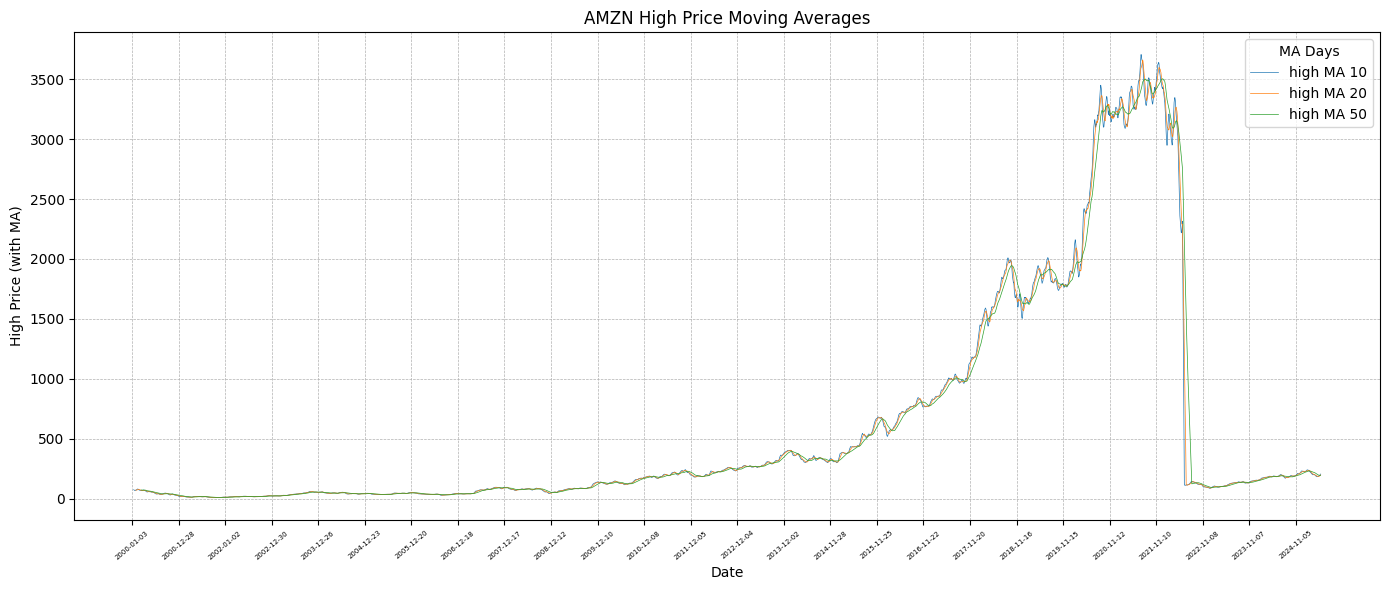

Saved AAPL dataset with MAs at: stock_data\with_MA\AAPL_with_MA.csv


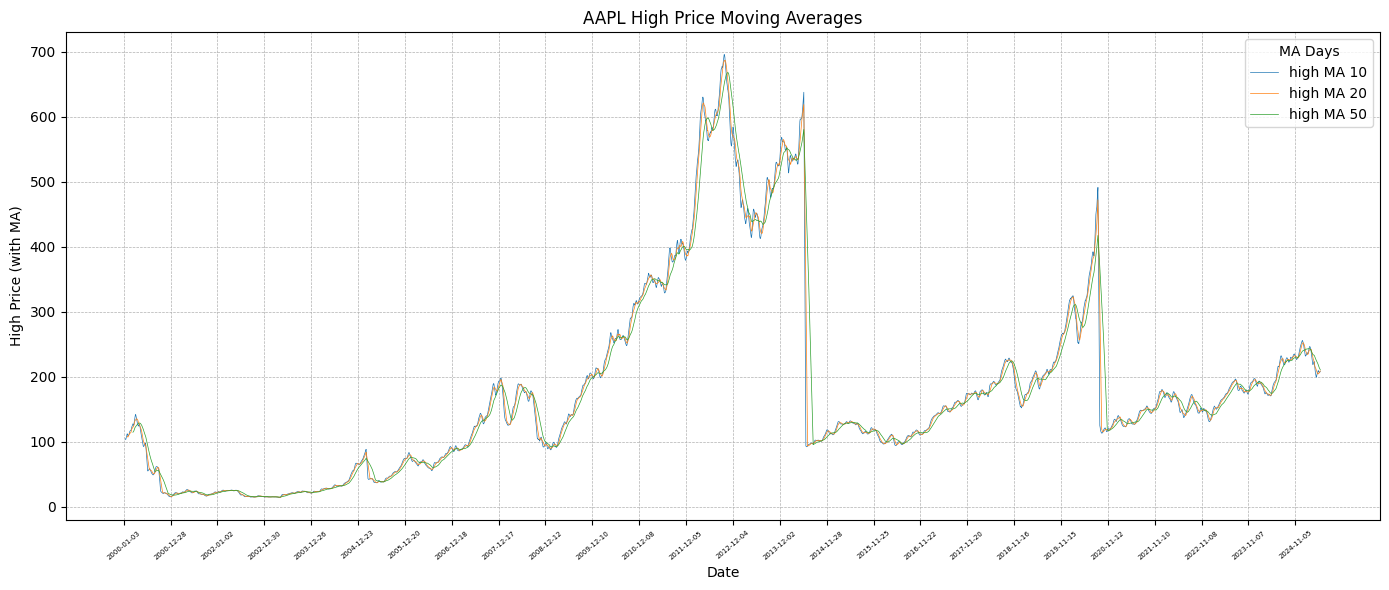

Saved GOOG dataset with MAs at: stock_data\with_MA\GOOG_with_MA.csv


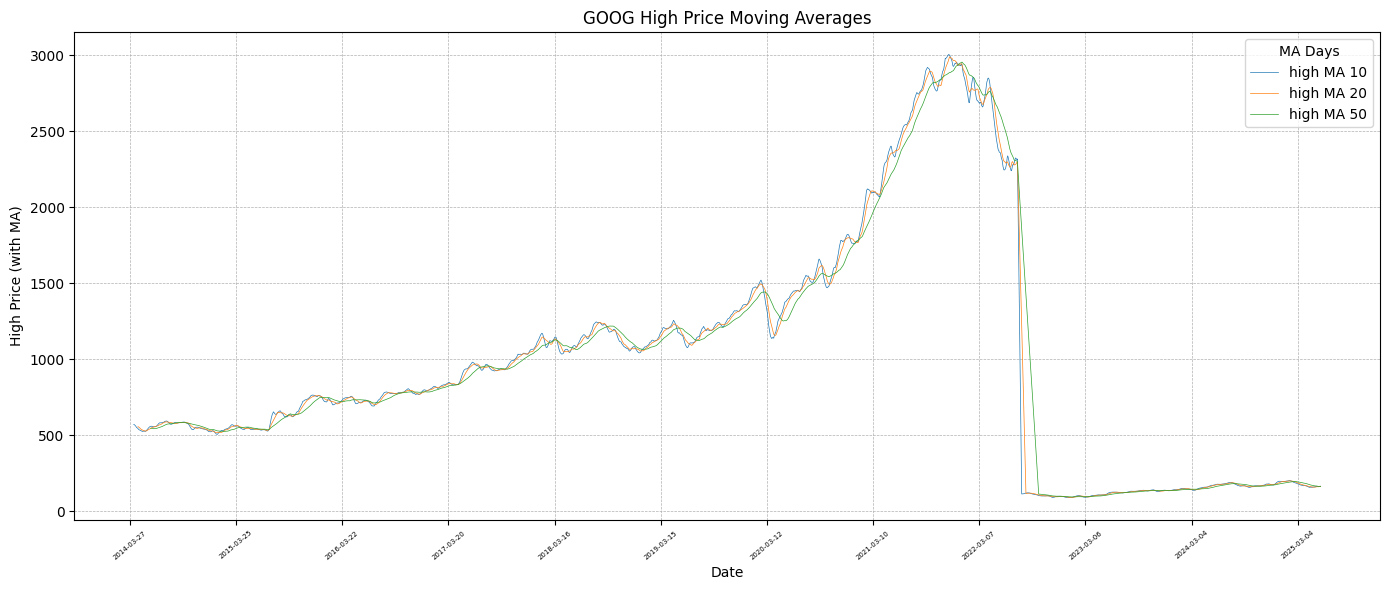

Saved META dataset with MAs at: stock_data\with_MA\META_with_MA.csv


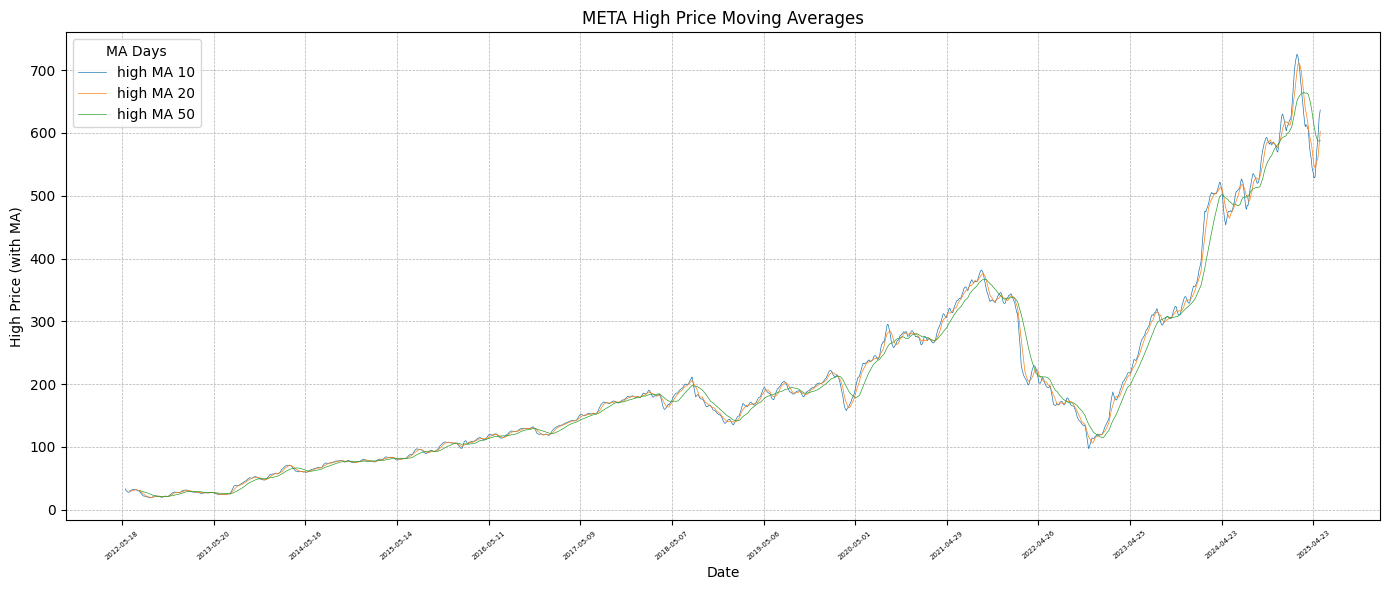

Saved MSFT dataset with MAs at: stock_data\with_MA\MSFT_with_MA.csv


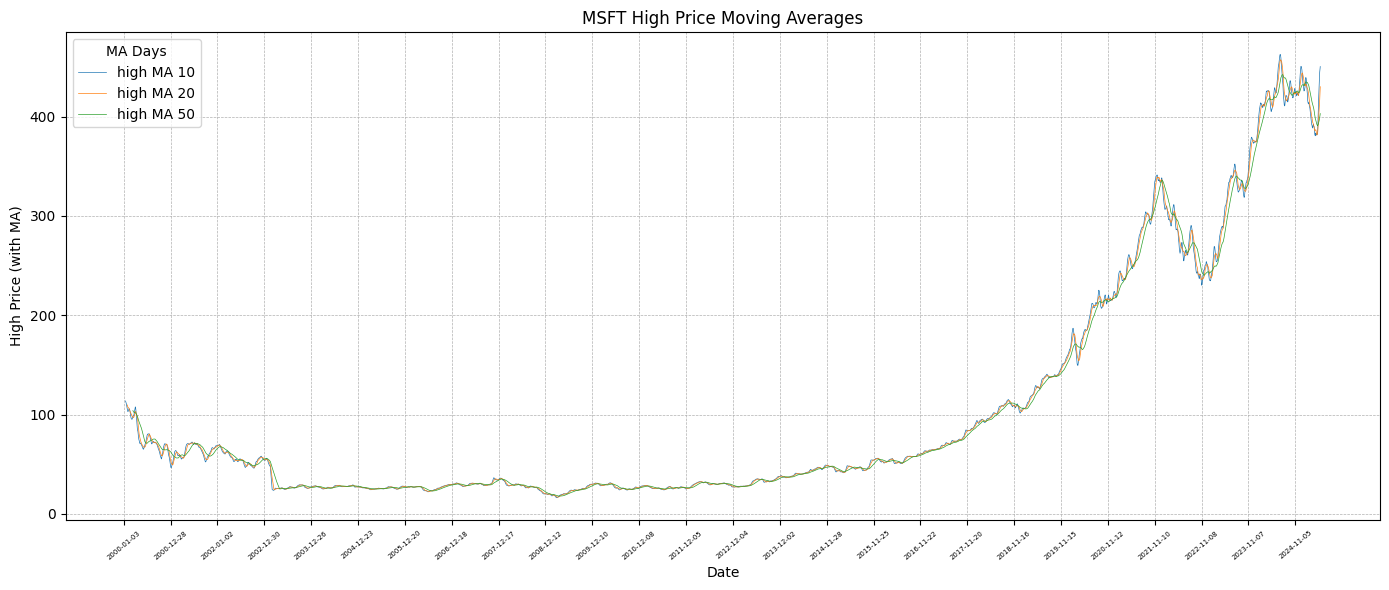

Saved NVDA dataset with MAs at: stock_data\with_MA\NVDA_with_MA.csv


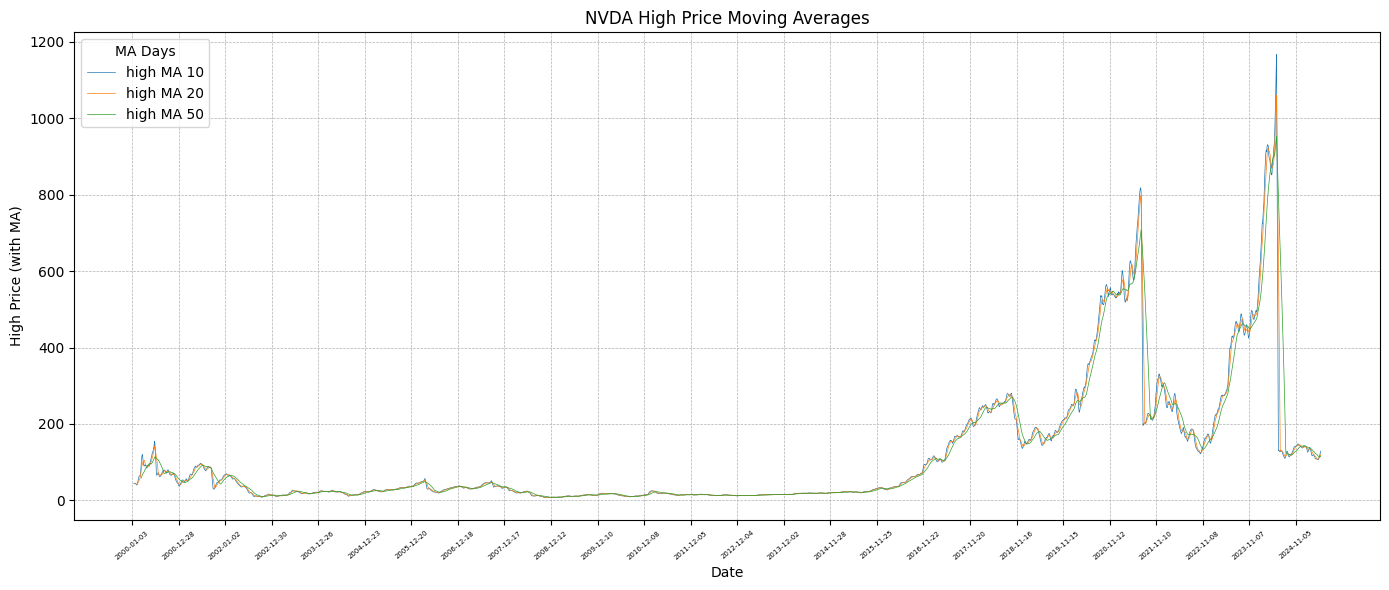

Saved TSLA dataset with MAs at: stock_data\with_MA\TSLA_with_MA.csv


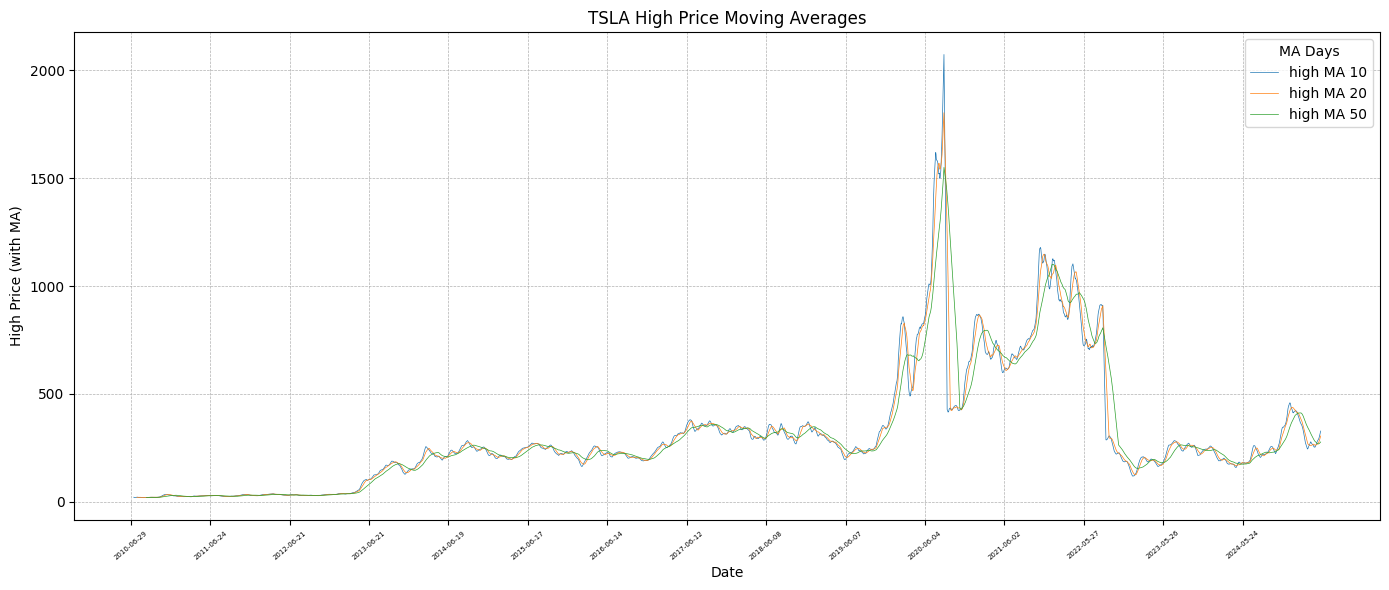

In [10]:
companies = ['AMZN', 'AAPL', 'GOOG', 'META', 'MSFT', 'NVDA', 'TSLA']
generate_moving_averages_csv(companies, save_fig=True)

In [6]:
def import_data(company):
    path = os.path.join(folder, f"{company}.csv")
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Unnamed: 0'])
    df = df.sort_values('Date').reset_index(drop=True)
    return df

def fit_model(company, X_train, Y_train, n_epochs):
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(64, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(25))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mean_squared_error')
    print(f"Training LSTM for {company}...")
    start = time.time()
    model.fit(X_train, Y_train, epochs=n_epochs, batch_size=16, verbose=1)
    end = time.time()
    print(f"Training time: {end - start:.2f} seconds")
    return model

def calculate_performance(company, Y_true, Y_pred, col):
    MSE = mean_squared_error(Y_true, Y_pred)
    RMSE = np.sqrt(MSE)  # Manually compute RMSE
    MAE = mean_absolute_error(Y_true, Y_pred)
    MAPE = mean_absolute_percentage_error(Y_true, Y_pred) * 100

    print(f"Performance for {company} - {col}:")
    print(f"MAE: {MAE:.2f}")
    print(f"MSE: {MSE:.2f}")
    print(f"RMSE: {RMSE:.2f}")
    print(f"MAPE: {MAPE:.2f}%\n")



def plot_predictions(company, col, Y_true, Y_pred, dates, save_fig=False):
    plt.figure(figsize=(12,6))
    plt.plot(dates, Y_true, label="Actual", color='red')
    plt.plot(dates, Y_pred, label="Predicted", color='blue')
    plt.xlabel("Date")
    plt.ylabel(f"{col} Price")
    plt.title(f"{company} {col} Price Prediction")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    if save_fig:
        save_path = os.path.join(folder, company, "Predictions")
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(os.path.join(save_path, f"{company}_{col}_prediction.png"), dpi=300)
    plt.show()

def generate_predictions(company, save_fig=False, train_ratio=0.8, n_epochs=50, interval=60):
    df = import_data(company)
    col = 'high'  # focusing on the high price
    data = df[[col]].values
    dates = df['Date']

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)

    training_data_len = int(len(data) * train_ratio)

    train_data = scaled_data[:training_data_len]
    test_data = scaled_data[training_data_len - interval:]

    X_train, Y_train = [], []
    for i in range(interval, len(train_data)):
        X_train.append(train_data[i-interval:i, 0])
        Y_train.append(train_data[i, 0])
    X_train, Y_train = np.array(X_train), np.array(Y_train)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

    X_test, Y_test = [], []
    for i in range(interval, len(test_data)):
        X_test.append(test_data[i-interval:i, 0])
        Y_test.append(test_data[i, 0])
    X_test, Y_test = np.array(X_test), np.array(Y_test)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    model = fit_model(company, X_train, Y_train, n_epochs)

    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)

    # Inverse transform to get actual prices
    Y_train_actual = scaler.inverse_transform(Y_train.reshape(-1,1))
    Y_train_pred_actual = scaler.inverse_transform(Y_train_pred)
    Y_test_actual = scaler.inverse_transform(Y_test.reshape(-1,1))
    Y_test_pred_actual = scaler.inverse_transform(Y_test_pred)

    calculate_performance(company, Y_train_actual, Y_train_pred_actual, col)
    calculate_performance(company, Y_test_actual, Y_test_pred_actual, col)

    # Plot train predictions (on training date range)
    plot_predictions(company, col, Y_train_actual.flatten(), Y_train_pred_actual.flatten(), dates[interval:training_data_len], save_fig=save_fig)
    # Plot test predictions (on test date range)
    plot_predictions(company, col, Y_test_actual.flatten(), Y_test_pred_actual.flatten(), dates[training_data_len:], save_fig=save_fig)

c:\Users\mahit\OneDrive\Desktop\UDEMY\python\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM for AMZN...
Epoch 1/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 59s 73ms/step - loss: 0.0029
Epoch 2/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - loss: 3.2207e-04
Epoch 3/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - loss: 2.5406e-04
Epoch 4/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 54s 127ms/step - loss: 2.1620e-04
Epoch 5/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 25s 80ms/step - loss: 2.0800e-04
Epoch 6/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 32s 99ms/step - loss: 2.1776e-04
Epoch 7/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 38s 88ms/step - loss: 2.3225e-04
Epoch 8/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 44s 97ms/step - loss: 2.3251e-04
Epoch 9/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - loss: 2.2611e-04
Epoch 10/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 24s 74ms/step - loss: 2.4702e-04
Epoch 11/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 44s 85ms/step - loss: 2.1232e-04
Epoch 12/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - loss: 2.0879e-04
Epoch 13/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 29s 93ms/step - loss: 2.4944e-04
Epoch 14/15
316/316 ━━━━

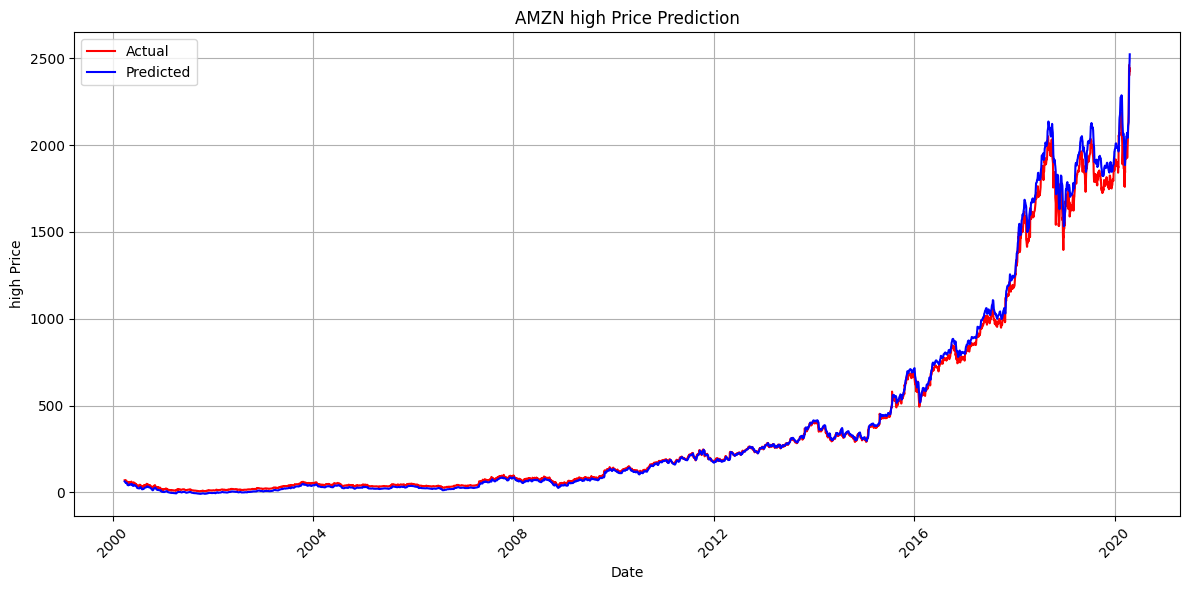

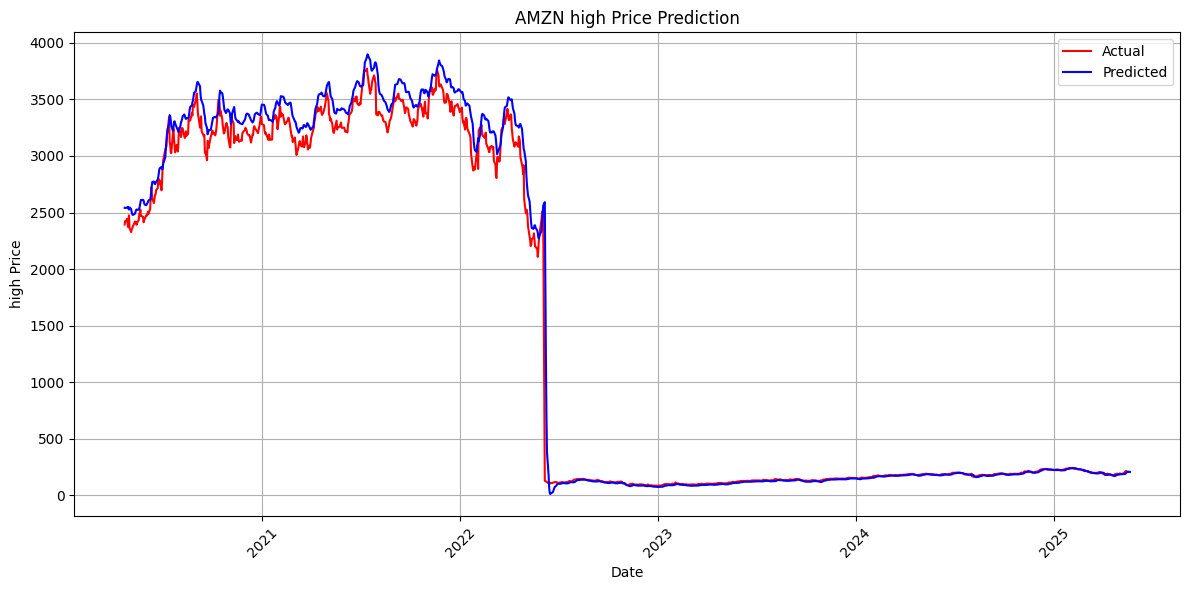

c:\Users\mahit\OneDrive\Desktop\UDEMY\python\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM for AAPL...
Epoch 1/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 39s 90ms/step - loss: 0.0058
Epoch 2/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - loss: 0.0020
Epoch 3/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - loss: 0.0017
Epoch 4/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 31s 97ms/step - loss: 0.0015
Epoch 5/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 27s 84ms/step - loss: 0.0013
Epoch 6/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - loss: 0.0014
Epoch 7/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - loss: 0.0013
Epoch 8/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - loss: 0.0012
Epoch 9/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 34s 70ms/step - loss: 0.0012
Epoch 10/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 40s 68ms/step - loss: 0.0012
Epoch 11/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - loss: 0.0011
Epoch 12/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - loss: 0.0011
Epoch 13/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - loss: 0.0011
Epoch 14/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - loss: 0.0011
Epo

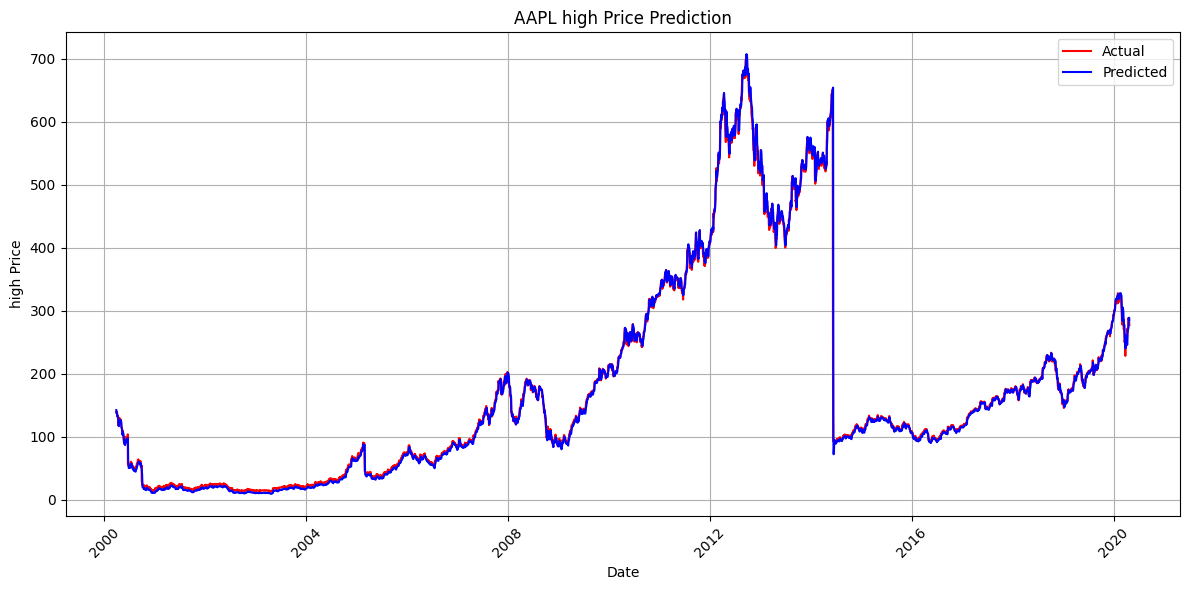

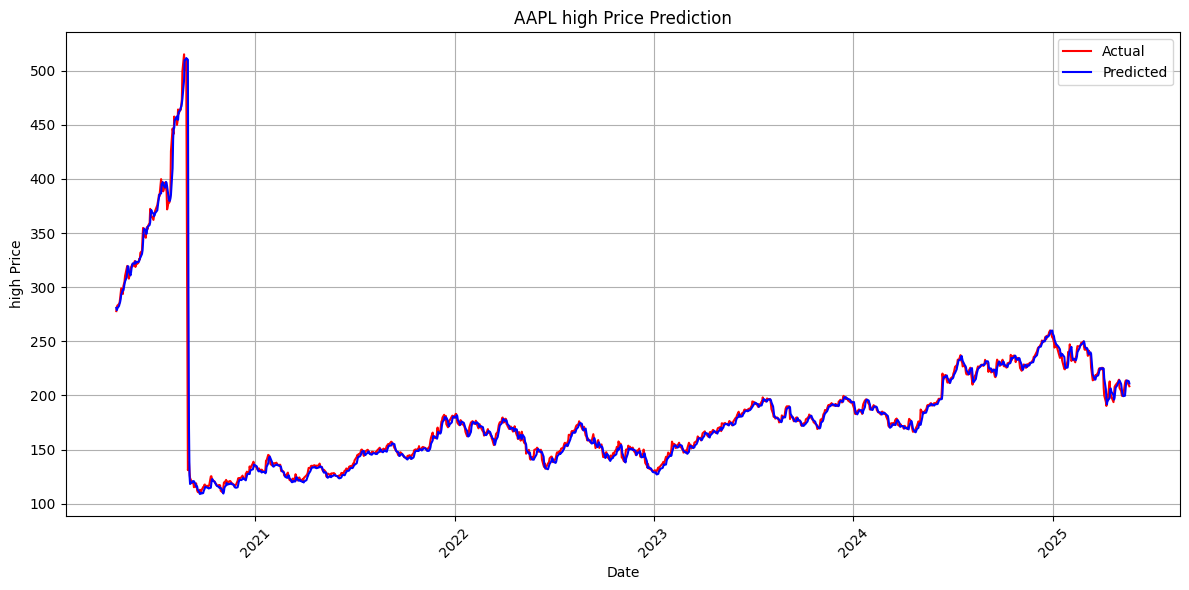

c:\Users\mahit\OneDrive\Desktop\UDEMY\python\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM for GOOG...
Epoch 1/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - loss: 0.0186
Epoch 2/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0024
Epoch 3/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0018
Epoch 4/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - loss: 0.0013
Epoch 5/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 0.0011
Epoch 6/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - loss: 0.0013
Epoch 7/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - loss: 0.0012
Epoch 8/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - loss: 9.5503e-04
Epoch 9/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - loss: 7.8434e-04
Epoch 10/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 8.2586e-04
Epoch 11/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 9.1265e-04
Epoch 12/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - loss: 7.7315e-04
Epoch 13/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - loss: 7.9458e-04
Epoch 14/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step -

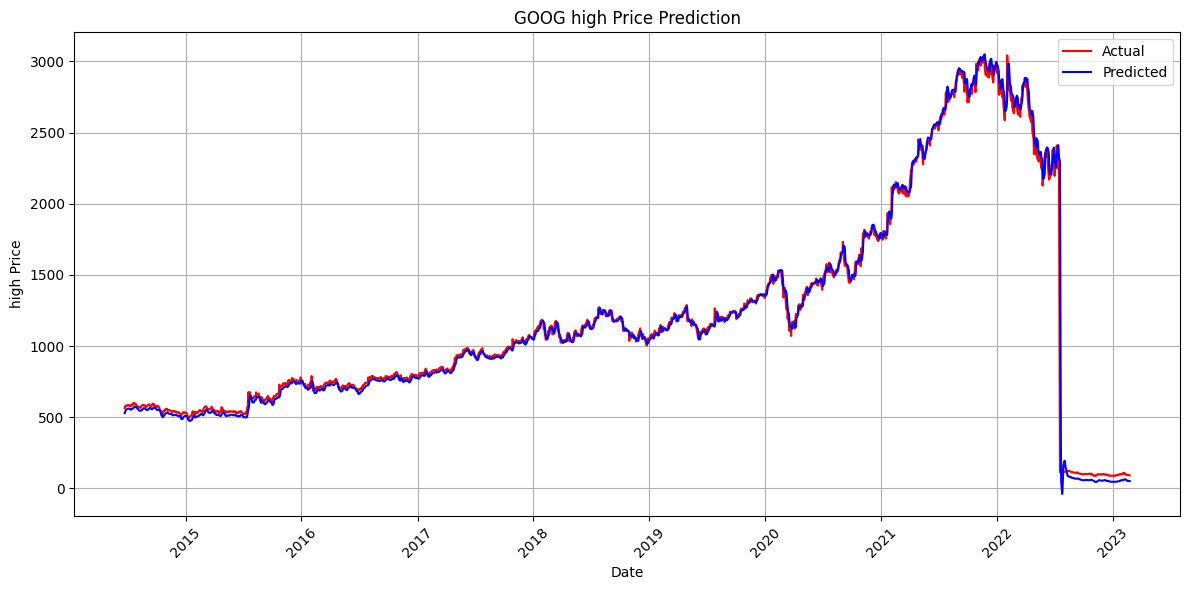

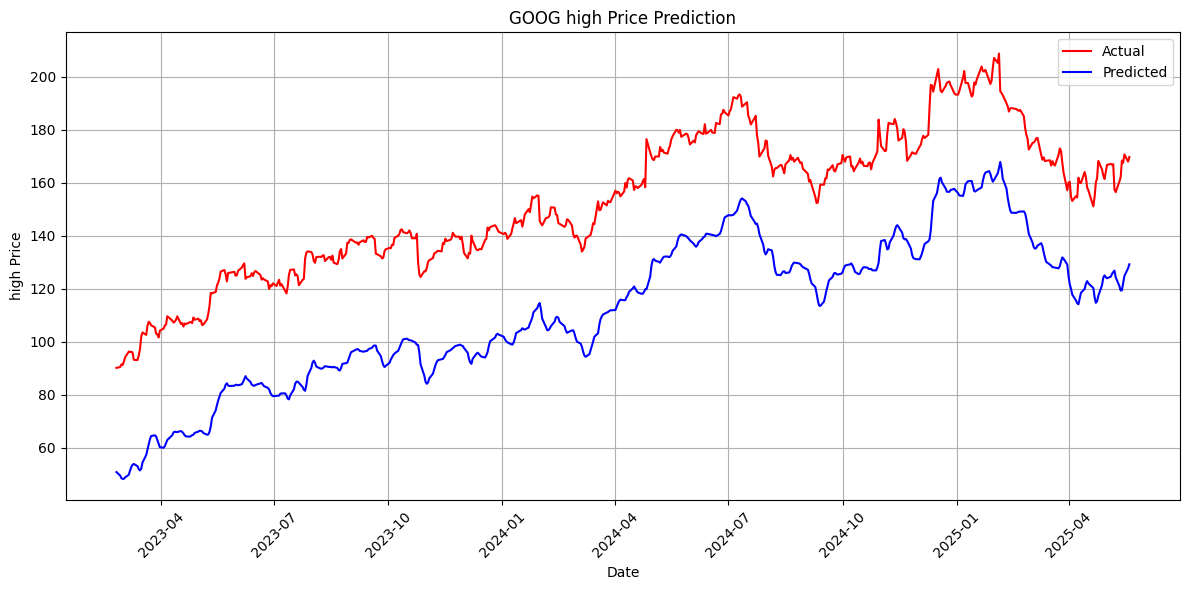

c:\Users\mahit\OneDrive\Desktop\UDEMY\python\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM for META...
Epoch 1/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - loss: 0.0043
Epoch 2/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - loss: 3.6372e-04
Epoch 3/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - loss: 3.5372e-04
Epoch 4/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - loss: 2.4461e-04
Epoch 5/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - loss: 2.6922e-04
Epoch 6/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - loss: 2.4961e-04
Epoch 7/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - loss: 2.0843e-04
Epoch 8/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - loss: 2.0959e-04
Epoch 9/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - loss: 2.1372e-04
Epoch 10/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - loss: 1.9416e-04
Epoch 11/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - loss: 2.1451e-04
Epoch 12/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - loss: 2.0112e-04
Epoch 13/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - loss: 2.0385e-04
Epoch 14/15
160/160 ━━━━━

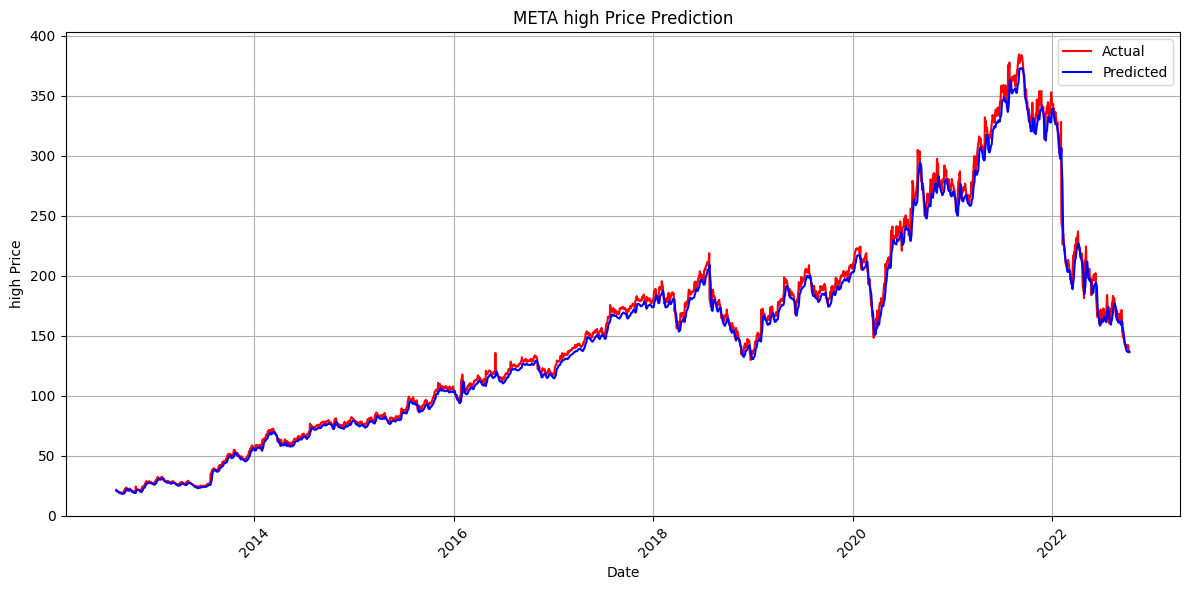

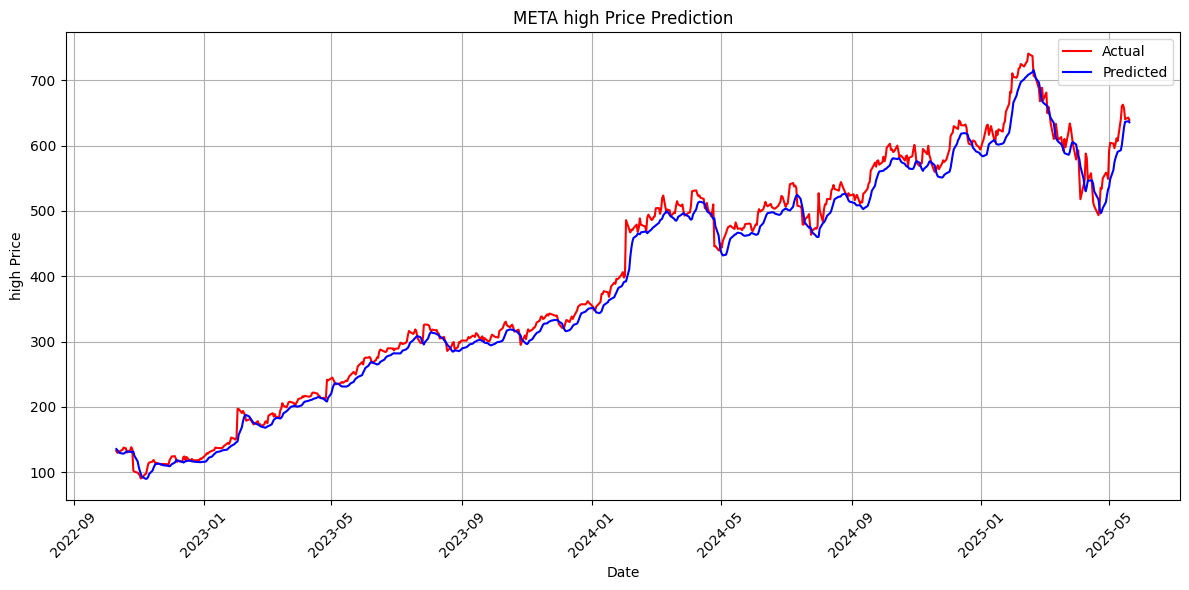

Training LSTM for MSFT...
Epoch 1/15


c:\Users\mahit\OneDrive\Desktop\UDEMY\python\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


316/316 ━━━━━━━━━━━━━━━━━━━━ 29s 67ms/step - loss: 6.6928e-04
Epoch 2/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - loss: 9.5864e-05
Epoch 3/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 42s 69ms/step - loss: 7.0657e-05
Epoch 4/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - loss: 7.3714e-05
Epoch 5/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - loss: 6.3208e-05
Epoch 6/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - loss: 6.1791e-05
Epoch 7/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - loss: 7.7717e-05
Epoch 8/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - loss: 8.2188e-05
Epoch 9/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step - loss: 5.4564e-05
Epoch 10/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 23s 71ms/step - loss: 7.3893e-05
Epoch 11/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - loss: 6.1222e-05
Epoch 12/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - loss: 5.0541e-05
Epoch 13/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 38s 59ms/step - loss: 6.8689e-05
Epoch 14/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - l

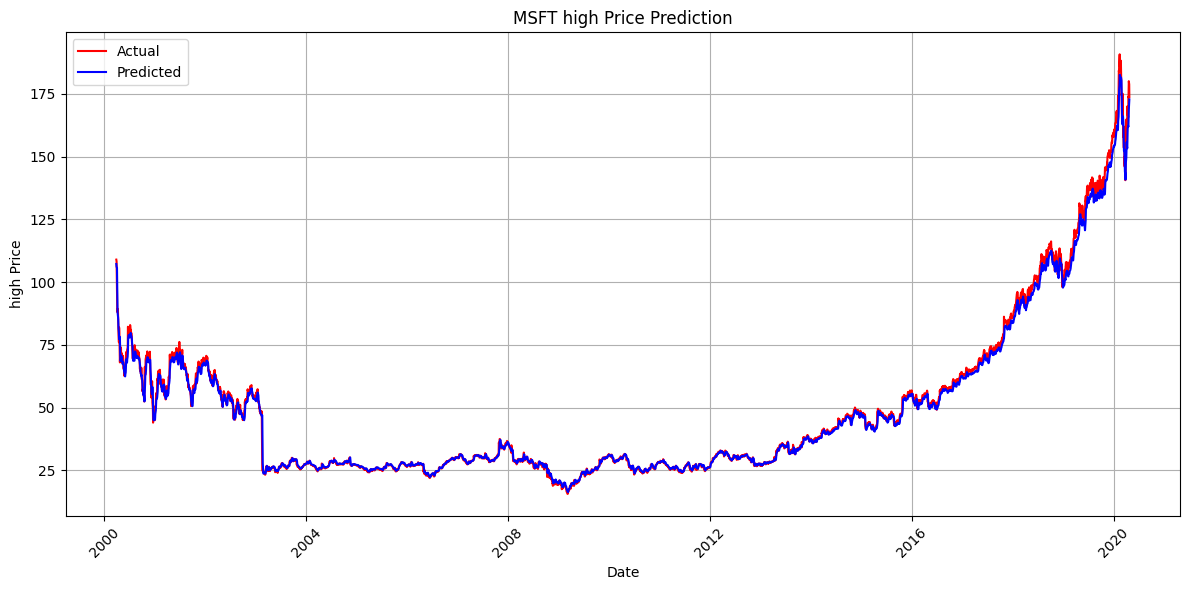

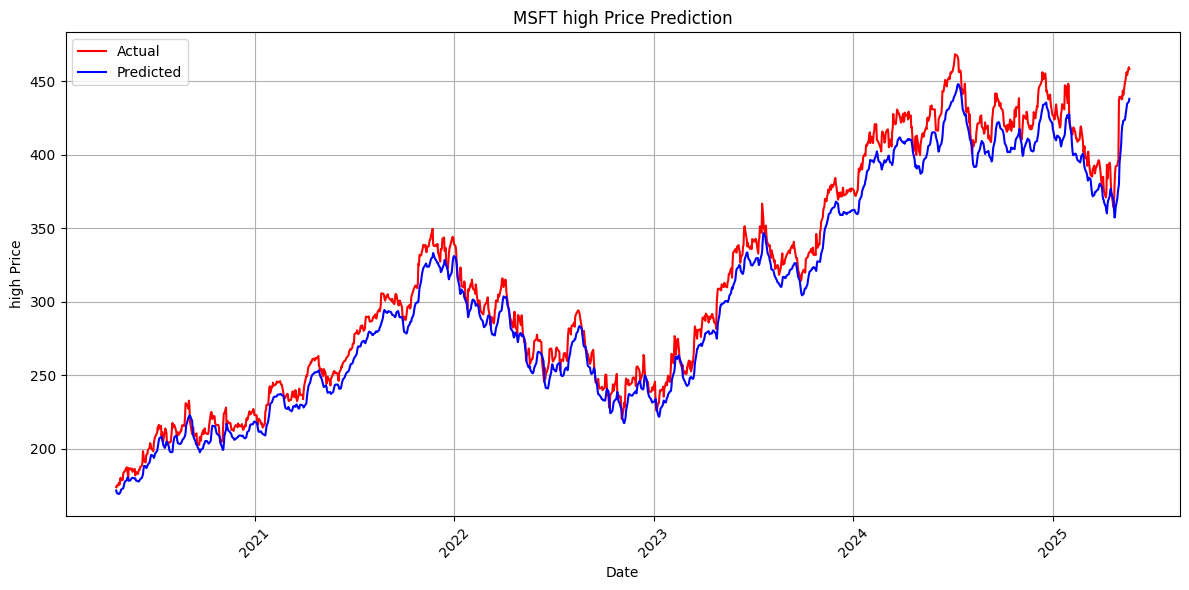

c:\Users\mahit\OneDrive\Desktop\UDEMY\python\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM for NVDA...
Epoch 1/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - loss: 3.6998e-04
Epoch 2/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - loss: 6.8410e-05
Epoch 3/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - loss: 6.1573e-05
Epoch 4/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - loss: 5.9852e-05
Epoch 5/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - loss: 5.2447e-05
Epoch 6/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - loss: 4.4059e-05
Epoch 7/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - loss: 4.1480e-05
Epoch 8/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - loss: 4.0057e-05
Epoch 9/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - loss: 4.3443e-05
Epoch 10/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - loss: 4.7075e-05
Epoch 11/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - loss: 4.6577e-05
Epoch 12/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - loss: 4.0933e-05
Epoch 13/15
316/316 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - loss: 4.8544e-05
Epoch 14/15
316/316 ━

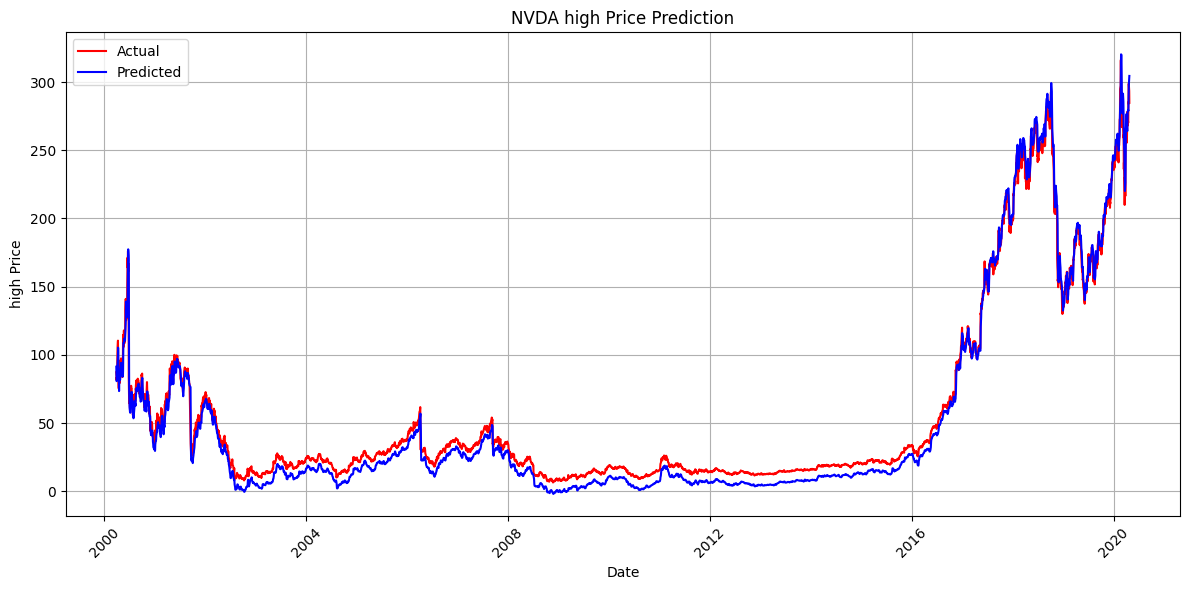

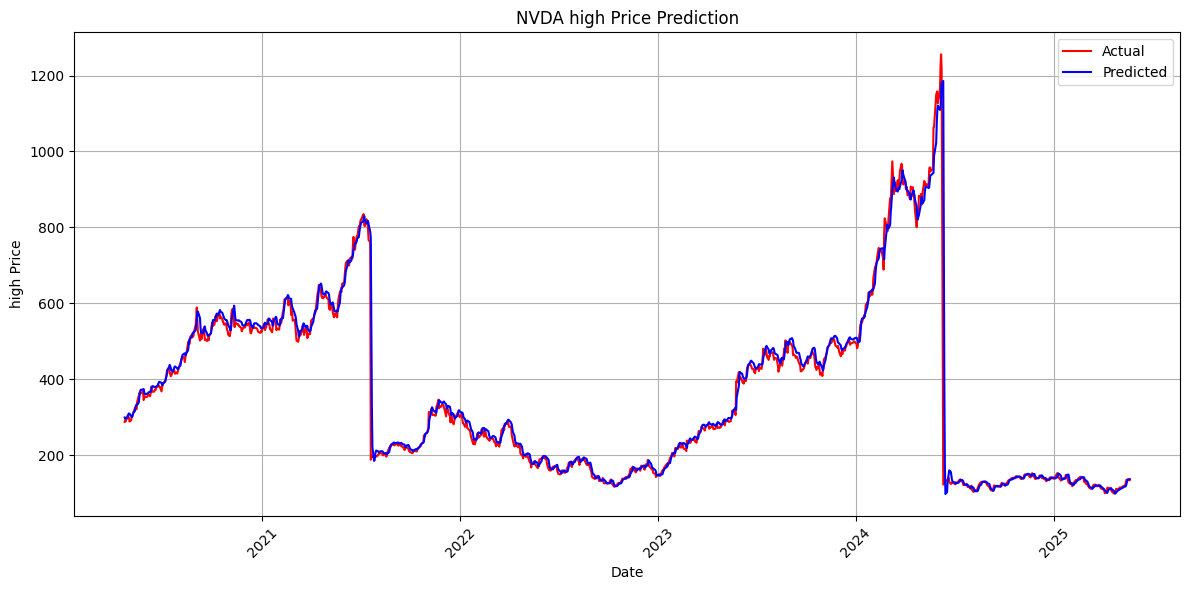

c:\Users\mahit\OneDrive\Desktop\UDEMY\python\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM for TSLA...
Epoch 1/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step - loss: 0.0049
Epoch 2/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - loss: 0.0015
Epoch 3/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - loss: 0.0016
Epoch 4/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - loss: 0.0012
Epoch 5/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - loss: 9.9736e-04
Epoch 6/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - loss: 9.1391e-04
Epoch 7/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - loss: 7.4254e-04
Epoch 8/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 9.4579e-04
Epoch 9/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - loss: 6.2868e-04
Epoch 10/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - loss: 6.8224e-04
Epoch 11/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 61ms/step - loss: 7.5870e-04
Epoch 12/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - loss: 7.5207e-04
Epoch 13/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - loss: 6.8484e-04
Epoch 14/15
184/184 ━━━━━━━━━━━━━━━━━

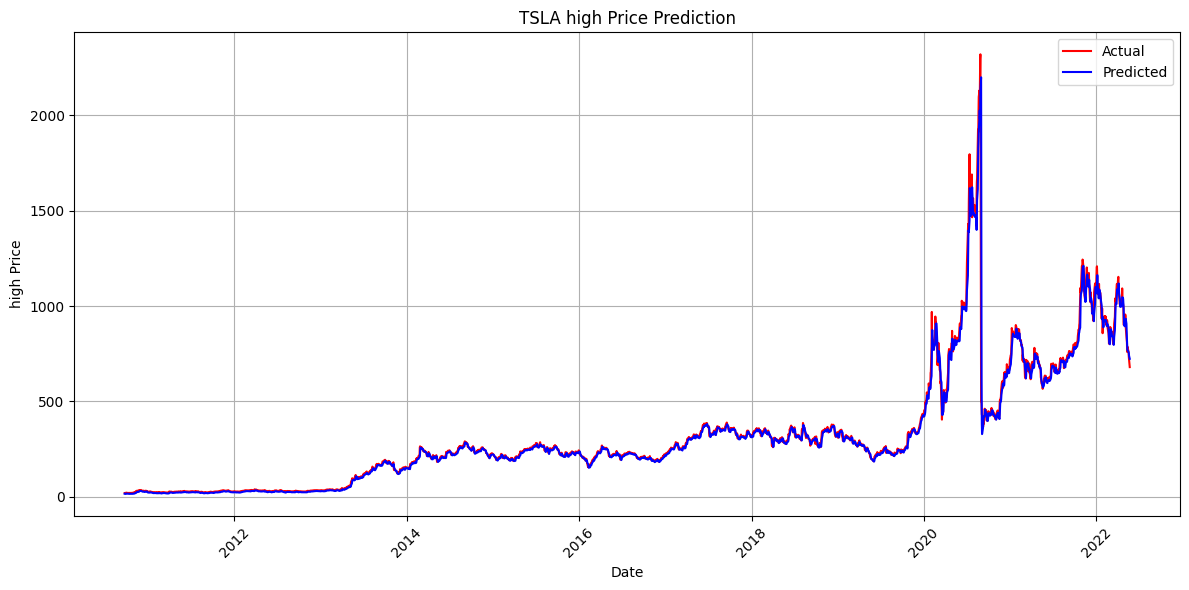

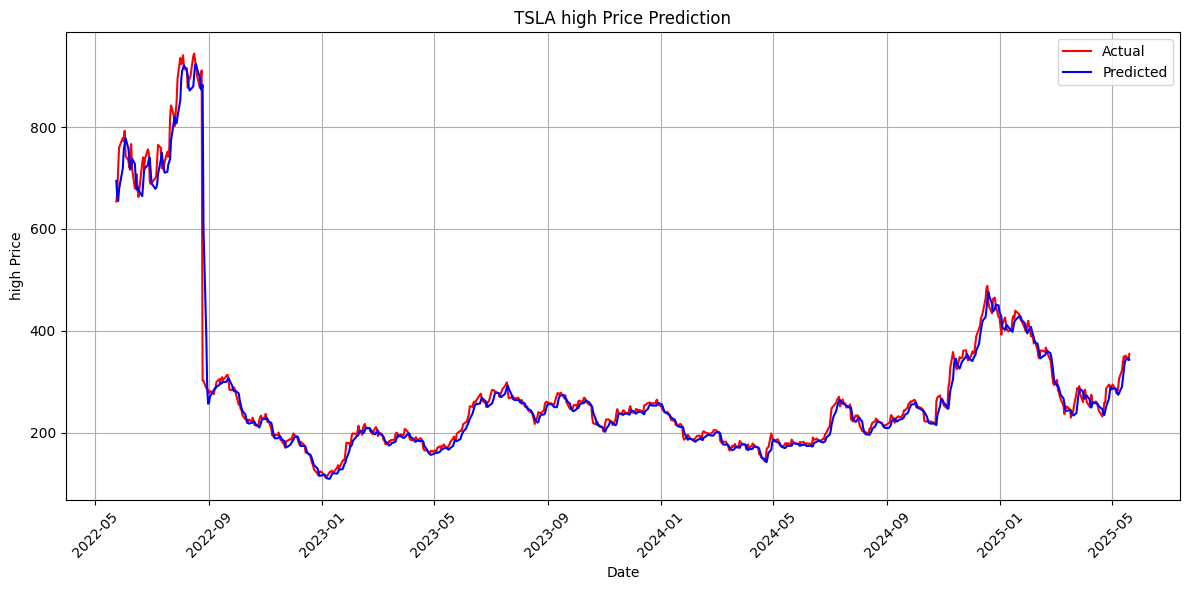

In [12]:
companies = ['AMZN', 'AAPL', 'GOOG', 'META', 'MSFT', 'NVDA', 'TSLA']
folder = 'stock_data'
# To run for all companies:
for company in companies:
    generate_predictions(company, save_fig=True, n_epochs=15)